In [1]:
%matplotlib widget

import os
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".4"

import abtem
import ase
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
from jax_multislice import (
    get_abtem_transmit, 
    Propagator as convolve2d, 
    energy2wavelength, 
    fresnel_propagation_kernel, 
    angular_spectrum_propagation_kernel, 
    relativistic_mass_correction,
    electron_refractive_index,
    wpm_step,
    transmission_function,
)

abtem.config.set({"device": "cpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)
# keep platform as GPU where available; change if needed
# jax.config.update("jax_platform_name", "gpu")

In [2]:
# Create a single Au atom in a small cell
atoms = ase.Atoms('Au', cell=[5, 5, 5], pbc=True)
atoms.center()

In [3]:
base_sampling = 0.0785 / 2
base_slice_thickness = 0.4

potential = abtem.Potential(
    atoms,
    sampling=base_sampling,
    slice_thickness=base_slice_thickness,
    projection='finite',
)
print('potential.shape =', potential.shape)

potential.shape = (13, 128, 128)


(<Figure size 1000x400 with 2 Axes>,
 <Axes: title={'center': 'Top view'}, xlabel='x [Å]', ylabel='z [Å]'>)

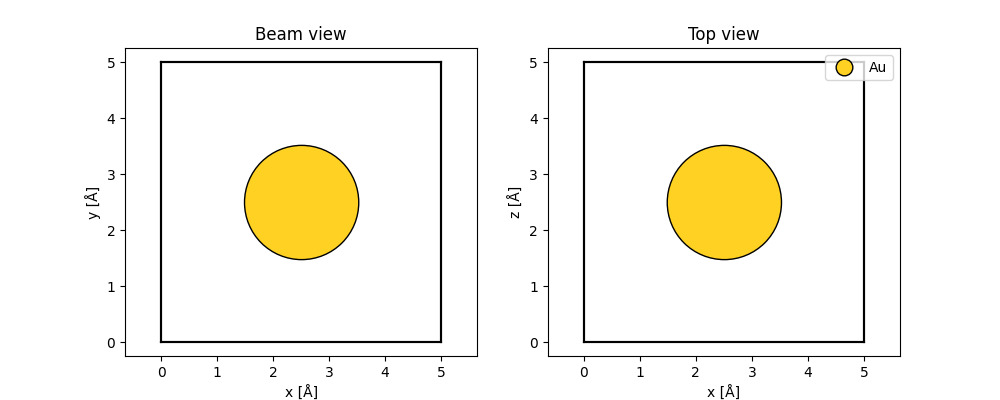

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
abtem.show_atoms(atoms, ax=ax1, title="Beam view", merge=False)
abtem.show_atoms(atoms, ax=ax2, plane="xz", title="Top view", legend=True)

In [5]:
energy = 200e3
transmit = get_abtem_transmit(potential, energy)


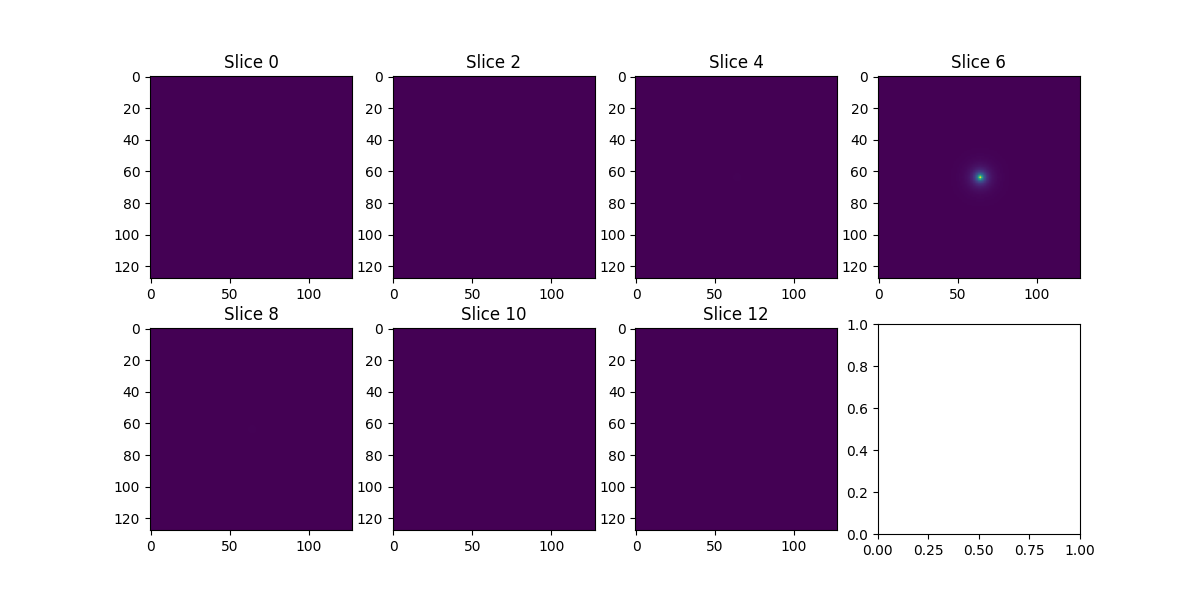

In [7]:
potential_array = potential.build(lazy=False).array
subset = potential_array[::2]

rows = int(np.floor(np.sqrt(len(subset))))
cols = int(np.ceil(np.sqrt(len(subset))))
if rows * cols < len(subset):
    cols += 1
fig, ax = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
vmin = potential_array.min()
vmax = potential_array.max()
for i, (p, s_ax) in enumerate(zip(subset, ax.ravel())):
    s_ax.imshow(p, vmin=vmin, vmax=vmax)
    s_ax.set_title(f"Slice {i * 2}")

In [8]:
wavelength = energy2wavelength(energy)
semiangle_cutoff = 100
defocus = 0
astigmatism = 0.,
astigmatism_angle = 0.,

probe = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    defocus=defocus,
)
probe.grid.match(potential)
probe_array = probe.build(lazy=False).array

W1209 17:06:07.988663 1772259 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1209 17:06:08.004411 1771848 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


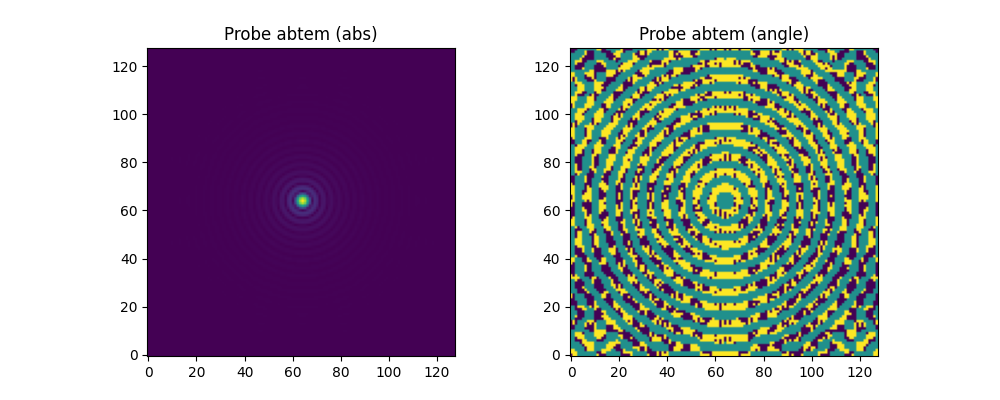

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(np.abs(probe.build(lazy=False).array), origin='lower')
ax1.set_title('Probe abtem (abs)');
ax2.imshow(np.angle(probe.build(lazy=False).array), origin='lower')
ax2.set_title('Probe abtem (angle)');

In [10]:
from tqdm import trange

def simulate_pattern_fresnel_as(object, probe, prop_kernel):
    wavefront = probe
    wavefronts = []

    for i in range(object.shape[0]):
        wavefront = wavefront * object[i]
        wavefront = convolve2d(wavefront, prop_kernel)
        wavefronts.append(wavefront)
    
    exit_wave = wavefront
    
    detector_wavefront = jnp.fft.fftshift(
        jnp.fft.fft2(wavefront)
    )
    diffraction_pattern = (
        jnp.square(detector_wavefront.real)
        + jnp.square(detector_wavefront.imag)
    )
    return exit_wave, diffraction_pattern, jnp.stack(wavefronts)

simulate_pattern_fresnel_as_jit = jax.jit(simulate_pattern_fresnel_as)

def simulate_pattern_wpm(potential, probe, dz, energy, ps):
    wavefront = probe
    wavefronts = []
    k0 = 2 * jnp.pi / energy2wavelength(energy)
    for i in trange(potential.shape[0], desc="WPM slices"):
        n = electron_refractive_index(potential[i], energy)
        phase_shift = k0 * (n - 1)
        wavefront = wpm_step(wavefront, n, dz, energy, ps)
        wavefronts.append(wavefront)
    
    exit_wave = wavefront
    
    detector_wavefront = jnp.fft.fftshift(
        jnp.fft.fft2(wavefront)
    )
    diffraction_pattern = (
        jnp.square(detector_wavefront.real)
        + jnp.square(detector_wavefront.imag)
    )
    return exit_wave, diffraction_pattern, jnp.stack(wavefronts)

simulate_pattern_wpm_jit = jax.jit(simulate_pattern_wpm)

In [20]:
# Extract sampling as separate values to ensure proper type handling
sampling_x, sampling_y = probe.grid.sampling[0], probe.grid.sampling[1]

fresnel_propagator = fresnel_propagation_kernel(
    probe.grid.gpts[0],
    probe.grid.gpts[1],
    (sampling_x, sampling_y),  # Pass as tuple explicitly
    z=base_slice_thickness,
    energy=probe.energy,
)

angular_spectrum_propagator = angular_spectrum_propagation_kernel(
    probe.grid.gpts[0],
    probe.grid.gpts[1],
    (sampling_x, sampling_y),  # Pass as tuple explicitly
    z=base_slice_thickness,
    energy=probe.energy,
)

exit_wave_fresnel, diffraction_pattern_fresnel, wavefronts_fresnel = simulate_pattern_fresnel_as_jit(transmit, probe_array, fresnel_propagator)
exit_wave_as, diffraction_pattern_as, wavefronts_as = simulate_pattern_fresnel_as_jit(transmit, probe_array, angular_spectrum_propagator)

In [21]:
exit_wave_wpm, diffraction_pattern_wpm, wavefronts_wpm = simulate_pattern_wpm(potential_array, probe_array, base_slice_thickness, energy, (sampling_x, sampling_y))


WPM slices: 100%|██████████| 13/13 [00:01<00:00, 12.24it/s]


## Quick Visual Check: First Wavefronts
Plot the first wavefront from each method (intensity).

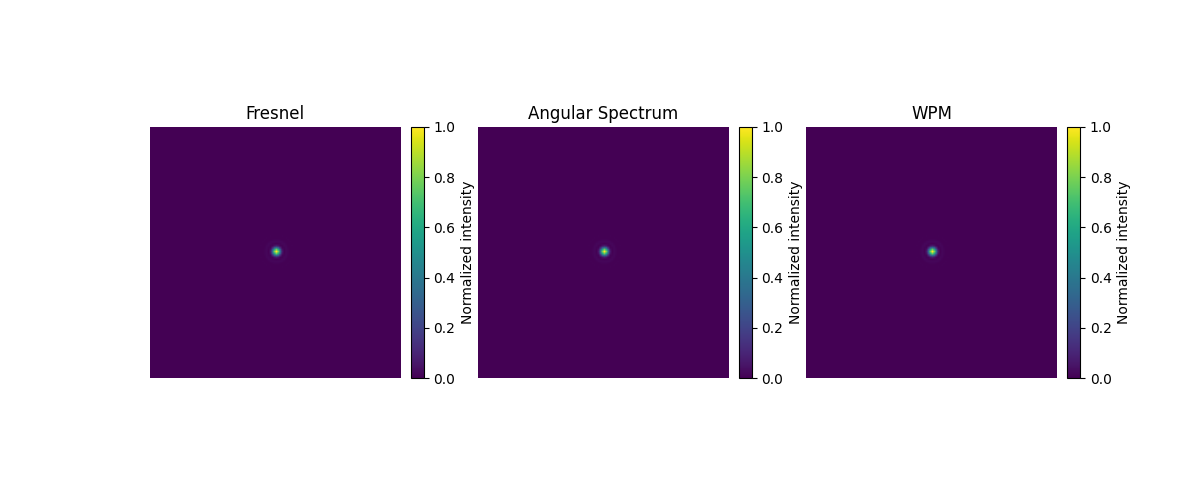

In [22]:
# plot first wavefront (index 0) for each method: Fresnel, Angular Spectrum, WPM
fig, axs = plt.subplots(1, 3, figsize=(12, 5))

wf_f = np.asarray(wavefronts_fresnel[0])
wf_a = np.asarray(wavefronts_as[0])
wf_w = np.asarray(wavefronts_wpm[0])

# plot intensity (|ψ|^2) with a shared color scale normalized to [0,1]
int_f = np.abs(wf_f) ** 2
int_a = np.abs(wf_a) ** 2
int_w = np.abs(wf_w) ** 2
# global max across the three methods to normalize for fair comparison
global_max = max(int_f.max(), int_a.max(), int_w.max()) if max(int_f.max(), int_a.max(), int_w.max()) > 0 else 1.0
int_f = (int_f / global_max).astype(np.float32)
int_a = (int_a / global_max).astype(np.float32)
int_w = (int_w / global_max).astype(np.float32)

imgs = [int_f, int_a, int_w]
titles = ["Fresnel", "Angular Spectrum", "WPM"]

for ax, img, title in zip(axs, imgs, titles):
    im = ax.imshow(img, origin='lower', cmap='viridis', vmin=0.0, vmax=1.0)
    ax.set_title(title)
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Normalized intensity")

## Slice-by-slice Comparison: Intensity and Phase (Normalized)
The plots below show cross-sections (center row) of the wavefronts for each slice. Intensities are normalized to the same global maximum so differences are directly comparable. Phases are wrapped to [-π, π].

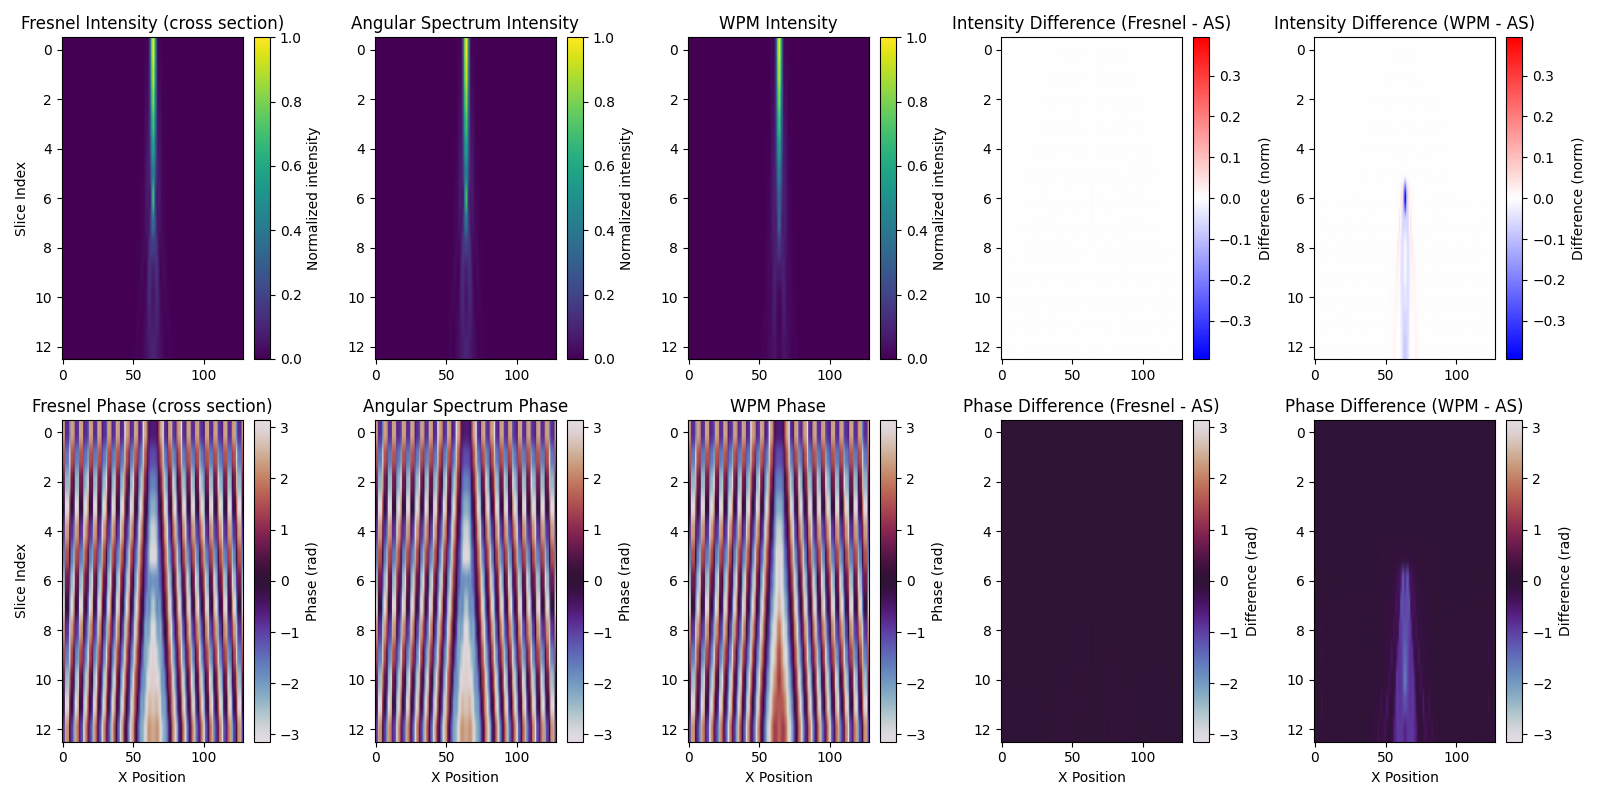

In [23]:
fig, ax = plt.subplots(2, 5, figsize=(16, 8))

# Calculate intensities (cross-section at center y). Convert to numpy arrays first
intensity_fresnel = np.abs(np.asarray(wavefronts_fresnel[:, wavefronts_fresnel.shape[1]//2, :]))**2
intensity_as = np.abs(np.asarray(wavefronts_as[:, wavefronts_as.shape[1]//2, :]))**2
intensity_wpm = np.abs(np.asarray(wavefronts_wpm[:, wavefronts_wpm.shape[1]//2, :]))**2

# Normalize using a single global maximum across all three methods
global_max = max(intensity_fresnel.max(), intensity_as.max(), intensity_wpm.max()) if max(intensity_fresnel.max(), intensity_as.max(), intensity_wpm.max()) > 0 else 1.0
intensity_fresnel = (intensity_fresnel / global_max).astype(np.float32)
intensity_as = (intensity_as / global_max).astype(np.float32)
intensity_wpm = (intensity_wpm / global_max).astype(np.float32)

# Intensity differences
intensity_diff_f_as = intensity_fresnel - intensity_as
intensity_diff_w_as = intensity_wpm - intensity_as

# Calculate phases
phase_fresnel = np.angle(np.asarray(wavefronts_fresnel[:, wavefronts_fresnel.shape[1]//2, :]))
phase_as = np.angle(np.asarray(wavefronts_as[:, wavefronts_as.shape[1]//2, :]))
phase_wpm = np.angle(np.asarray(wavefronts_wpm[:, wavefronts_wpm.shape[1]//2, :]))

# Phase differences and wrap to [-pi, pi]
phase_diff_f_as = (phase_fresnel - phase_as + np.pi) % (2 * np.pi) - np.pi
phase_diff_w_as = (phase_wpm - phase_as + np.pi) % (2 * np.pi) - np.pi

# --- Row 1: Intensity ---
# Fresnel
im_fresnel = ax[0, 0].imshow(intensity_fresnel, aspect='auto', origin='upper', vmin=0.0, vmax=1.0, cmap='viridis')
ax[0, 0].set_title("Fresnel Intensity (cross section)")
ax[0, 0].set_ylabel("Slice Index")
fig.colorbar(im_fresnel, ax=ax[0, 0], label="Normalized intensity")

# Angular Spectrum
im_as = ax[0, 1].imshow(intensity_as, aspect='auto', origin='upper', vmin=0.0, vmax=1.0, cmap='viridis')
ax[0, 1].set_title("Angular Spectrum Intensity")
fig.colorbar(im_as, ax=ax[0, 1], label="Normalized intensity")

# WPM
im_wpm = ax[0, 2].imshow(intensity_wpm, aspect='auto', origin='upper', vmin=0.0, vmax=1.0, cmap='viridis')
ax[0, 2].set_title("WPM Intensity")
fig.colorbar(im_wpm, ax=ax[0, 2], label="Normalized intensity")

# Intensity Difference (Fresnel - AS)
vmax_diff = np.max(np.abs(np.stack([intensity_diff_f_as, intensity_diff_w_as]))) if np.max(np.abs(np.stack([intensity_diff_f_as, intensity_diff_w_as])))>0 else 1.0
im_diff_f_as = ax[0, 3].imshow(intensity_diff_f_as, aspect='auto', origin='upper', cmap='bwr', vmin=-vmax_diff, vmax=vmax_diff)
ax[0, 3].set_title("Intensity Difference (Fresnel - AS)")
fig.colorbar(im_diff_f_as, ax=ax[0, 3], label="Difference (norm)")

# Intensity Difference (WPM - AS)
im_diff_w_as = ax[0, 4].imshow(intensity_diff_w_as, aspect='auto', origin='upper', cmap='bwr', vmin=-vmax_diff, vmax=vmax_diff)
ax[0, 4].set_title("Intensity Difference (WPM - AS)")
fig.colorbar(im_diff_w_as, ax=ax[0, 4], label="Difference (norm)")

# --- Row 2: Phase ---
# Fresnel Phase
p_fresnel = ax[1, 0].imshow(phase_fresnel, aspect='auto', origin='upper', cmap='twilight', vmin=-np.pi, vmax=np.pi)
ax[1, 0].set_title("Fresnel Phase (cross section)")
ax[1, 0].set_xlabel("X Position")
ax[1, 0].set_ylabel("Slice Index")
fig.colorbar(p_fresnel, ax=ax[1, 0], label="Phase (rad)")

# Angular Spectrum Phase
p_as = ax[1, 1].imshow(phase_as, aspect='auto', origin='upper', cmap='twilight', vmin=-np.pi, vmax=np.pi)
ax[1, 1].set_title("Angular Spectrum Phase")
ax[1, 1].set_xlabel("X Position")
fig.colorbar(p_as, ax=ax[1, 1], label="Phase (rad)")

# WPM Phase
p_wpm = ax[1, 2].imshow(phase_wpm, aspect='auto', origin='upper', cmap='twilight', vmin=-np.pi, vmax=np.pi)
ax[1, 2].set_title("WPM Phase")
ax[1, 2].set_xlabel("X Position")
fig.colorbar(p_wpm, ax=ax[1, 2], label="Phase (rad)")

# Phase Difference (Fresnel - AS)
im_diff_phase_f_as = ax[1, 3].imshow(phase_diff_f_as, aspect='auto', origin='upper', cmap='twilight', vmin=-np.pi, vmax=np.pi)
ax[1, 3].set_title("Phase Difference (Fresnel - AS)")
ax[1, 3].set_xlabel("X Position")
fig.colorbar(im_diff_phase_f_as, ax=ax[1, 3], label="Difference (rad)")

# Phase Difference (WPM - AS)
im_diff_phase_w_as = ax[1, 4].imshow(phase_diff_w_as, aspect='auto', origin='upper', cmap='twilight', vmin=-np.pi, vmax=np.pi)
ax[1, 4].set_title("Phase Difference (WPM - AS)")
ax[1, 4].set_xlabel("X Position")
fig.colorbar(im_diff_phase_w_as, ax=ax[1, 4], label="Difference (rad)")

plt.tight_layout()

## Exit Wave & Diffraction Pattern Comparison (Normalized)
Exit waves and diffraction patterns are normalized per-image to the range [0,1] for display. Differences use a symmetric diverging colormap.

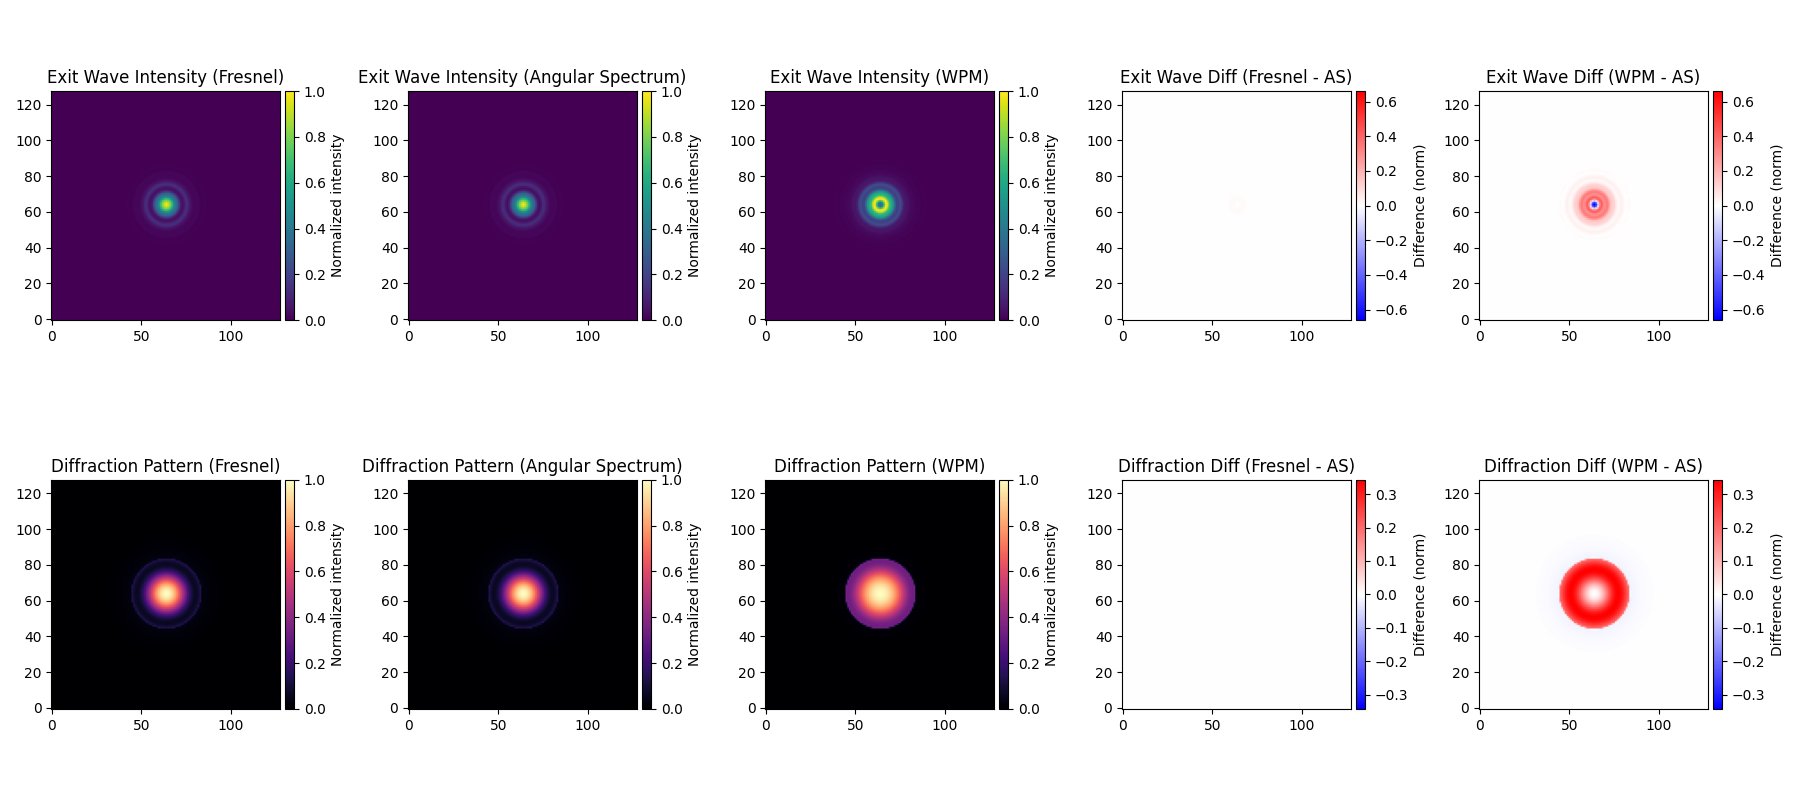

In [24]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axs = plt.subplots(2, 5, figsize=(18, 8))

# helper to create cax with same height as axis
def add_colorbar(ax, im, size="4%", pad=0.05, **kwargs):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size=size, pad=pad)
    return fig.colorbar(im, cax=cax, **kwargs)

# --- Row 1: Exit Wave Intensity ---
ew_f = np.abs(np.asarray(exit_wave_fresnel))**2
ew_a = np.abs(np.asarray(exit_wave_as))**2
ew_w = np.abs(np.asarray(exit_wave_wpm))**2

def norm01(x):
    m = x.max() if x.max()!=0 else 1.0
    return (x / m).astype(np.float32)

ew_f_n = norm01(ew_f)
ew_a_n = norm01(ew_a)
ew_w_n = norm01(ew_w)

im = axs[0, 0].imshow(ew_f_n, origin='lower', vmin=0.0, vmax=1.0, cmap='viridis')
axs[0, 0].set_title("Exit Wave Intensity (Fresnel)")
add_colorbar(axs[0, 0], im, label="Normalized intensity")

im = axs[0, 1].imshow(ew_a_n, origin='lower', vmin=0.0, vmax=1.0, cmap='viridis')
axs[0, 1].set_title("Exit Wave Intensity (Angular Spectrum)")
add_colorbar(axs[0, 1], im, label="Normalized intensity")

im = axs[0, 2].imshow(ew_w_n, origin='lower', vmin=0.0, vmax=1.0, cmap='viridis')
axs[0, 2].set_title("Exit Wave Intensity (WPM)")
add_colorbar(axs[0, 2], im, label="Normalized intensity")

diff_ew_f_as = ew_f_n - ew_a_n
diff_ew_w_as = ew_w_n - ew_a_n
vmax_ew = np.max(np.abs(np.stack([diff_ew_f_as, diff_ew_w_as]))) if np.max(np.abs(np.stack([diff_ew_f_as, diff_ew_w_as])))>0 else 1.0

im = axs[0, 3].imshow(diff_ew_f_as, cmap='bwr', origin='lower', vmin=-vmax_ew, vmax=vmax_ew)
axs[0, 3].set_title("Exit Wave Diff (Fresnel - AS)")
add_colorbar(axs[0, 3], im, label="Difference (norm)")

im = axs[0, 4].imshow(diff_ew_w_as, cmap='bwr', origin='lower', vmin=-vmax_ew, vmax=vmax_ew)
axs[0, 4].set_title("Exit Wave Diff (WPM - AS)")
add_colorbar(axs[0, 4], im, label="Difference (norm)")


# --- Row 2: Diffraction Pattern Intensity ---
dp_f = np.asarray(diffraction_pattern_fresnel)
dp_a = np.asarray(diffraction_pattern_as)
dp_w = np.asarray(diffraction_pattern_wpm)

dp_f_n = norm01(dp_f)
dp_a_n = norm01(dp_a)
dp_w_n = norm01(dp_w)

im = axs[1, 0].imshow(dp_f_n, origin='lower', vmin=0.0, vmax=1.0, cmap='magma')
axs[1, 0].set_title("Diffraction Pattern (Fresnel)")
add_colorbar(axs[1, 0], im, label="Normalized intensity")

im = axs[1, 1].imshow(dp_a_n, origin='lower', vmin=0.0, vmax=1.0, cmap='magma')
axs[1, 1].set_title("Diffraction Pattern (Angular Spectrum)")
add_colorbar(axs[1, 1], im, label="Normalized intensity")

im = axs[1, 2].imshow(dp_w_n, origin='lower', vmin=0.0, vmax=1.0, cmap='magma')
axs[1, 2].set_title("Diffraction Pattern (WPM)")
add_colorbar(axs[1, 2], im, label="Normalized intensity")

diff_dp_f_as = dp_f_n - dp_a_n
diff_dp_w_as = dp_w_n - dp_a_n
vmax_dp = np.max(np.abs(np.stack([diff_dp_f_as, diff_dp_w_as]))) if np.max(np.abs(np.stack([diff_dp_f_as, diff_dp_w_as])))>0 else 1.0

im = axs[1, 3].imshow(diff_dp_f_as, cmap='bwr', origin='lower', vmin=-vmax_dp, vmax=vmax_dp)
axs[1, 3].set_title("Diffraction Diff (Fresnel - AS)")
add_colorbar(axs[1, 3], im, label="Difference (norm)")

im = axs[1, 4].imshow(diff_dp_w_as, cmap='bwr', origin='lower', vmin=-vmax_dp, vmax=vmax_dp)
axs[1, 4].set_title("Diffraction Diff (WPM - AS)")
add_colorbar(axs[1, 4], im, label="Difference (norm)")

plt.tight_layout()